# Iris Classifier
Phần tiếp theo của Variational Classifier. This section focus in convert classical vector to quantum vector state. It not as simple as when we did in Variational Classifier.


In [1]:
import pennylane as qp
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer

In [2]:
np.random.seed(0)

In [3]:
# define a device
dev = qp.device("default.qubit")

## Encoding

- Will it harder? In fact, in machine learning x is a vector. Otherwise, x is a set of angles in quantum machine learning to create quantum state that is contained infomation. And the phase convert from vector to quantum state or set of angles called data encoding or feature mapping.
- But set of angles may have negative numbers so to simplify, focusing on positive subspace help us ignore signs which is require more computations.
- ref: https://pennylane.ai/qml/demos/tutorial_variational_classifier

In [4]:
def get_angles(x):
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))

    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

def state_preparation(a):
    qp.RY(a[0], wires = 0)

    qp.CNOT(wires=[0, 1])
    qp.RY(a[1], wires=1)
    qp.CNOT(wires=[0, 1])
    qp.RY(a[2], wires=1)

    qp.PauliX(wires=0)
    qp.CNOT(wires=[0, 1])
    qp.RY(a[3], wires=1)
    qp.CNOT(wires=[0, 1])
    qp.RY(a[4], wires=1)
    qp.PauliX(wires=0)

In [5]:
x = np.array([0.53896774,
              0.79503606,
              0.27826503,
              0.0
            ], requires_grad=False)
ang = get_angles(x)
print(ang)

[ 0.56397465 -0.          0.         -0.97504604  0.97504604]


In [6]:
@qp.qnode(dev)
def test(angles):
    state_preparation(angles)

    return qp.state()

state = test(ang)

print("x               : ", np.round(x, 6))
print("angles          : ", np.round(ang, 6))
print("amplitude vector: ", np.round(np.real(state), 6))

x               :  [0.538968 0.795036 0.278265 0.      ]
angles          :  [ 0.563975 -0.        0.       -0.975046  0.975046]
amplitude vector:  [ 0.538968  0.795036  0.278265 -0.      ]


(<Figure size 1200x300 with 1 Axes>, <Axes: >)

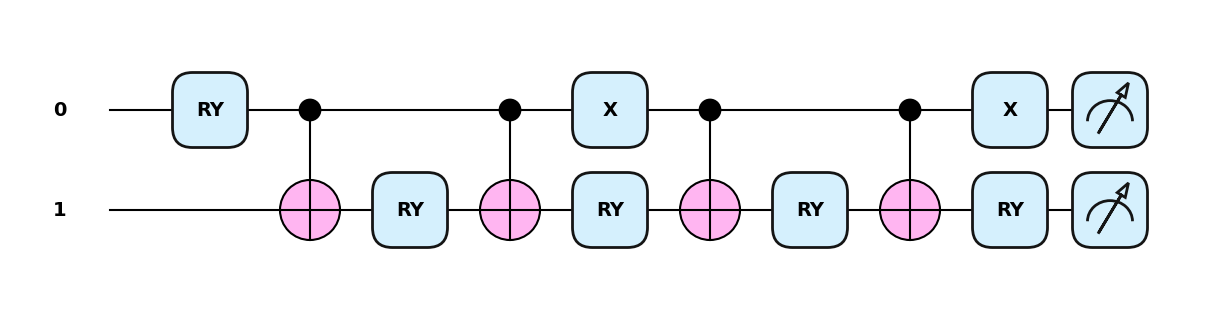

In [7]:
qp.drawer.use_style('pennylane')
qp.draw_mpl(test)(ang)

## Declare Model

In [8]:
def layer(layer_weights):
    for wire in range(2):
        qp.Rot(*layer_weights[wire], wires=wire)

    qp.CNOT(wires=[0,1])


In [9]:
# declare variational classifier
@qp.qnode(dev)
def circuit(weights, x):
    # qp.BasisState(x, wires=[0, 1, 2, 3])
    state_preparation(x)

    for layer_weights in weights:
        layer(layer_weights)
    
    return qp.expval(qp.PauliZ(0))

def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias


def square_loss(labels, predictions):
    return np.mean((labels - qp.math.stack(predictions)) ** 2)

# Evaluation
def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

In [10]:


def cost(weights, bias, X, Y):
    # Transpose the batch of input data in order to make the indexing
    # in state_preparation work
    predictions = variational_classifier(weights, bias, X.T)
    return square_loss(Y, predictions)

In [11]:
data = np.loadtxt("variational_classifier/iris_classes1and2_scaled.txt")
X = data[:, 0:2]
print(f"First X sample (original) : {X[0]}")

#pad the vectors to size 2^2 = 4 with constant values
padding = np.ones((len(X), 2)) * 0.1
X_pad = np.c_[X, padding]
print(f"First X sample (padded) : {X_pad[0]}")

#normalization each input
normalization = np.sqrt(np.sum(X_pad ** 2, -1))
X_norm = (X_pad.T / normalization).T
print(f"First X sample (normalized): {X_norm[0]}")

# the angles for state preparation are the features
features = np.array([get_angles(x) for x in X_norm], requires_grad=False)
print(f"First features samples : {features[0]}")

Y = data[:, -1]
print(f"First labels sample: {Y[0]}")


First X sample (original) : [0.4  0.75]
First X sample (padded) : [0.4  0.75 0.1  0.1 ]
First X sample (normalized): [0.46420708 0.87038828 0.11605177 0.11605177]
First features samples : [ 0.32973573 -0.78539816  0.78539816 -1.080839    1.080839  ]
First labels sample: -1.0


## Visualize Features

In [12]:
import matplotlib.pyplot as plt


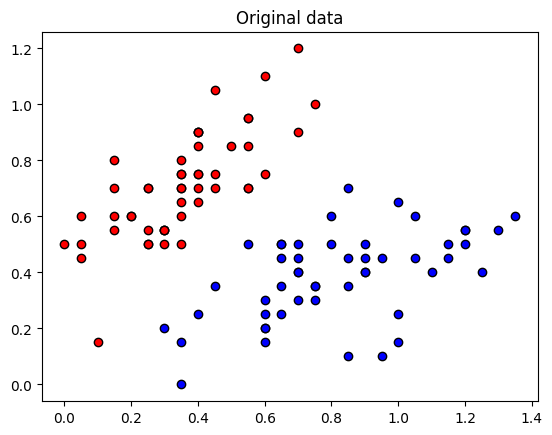

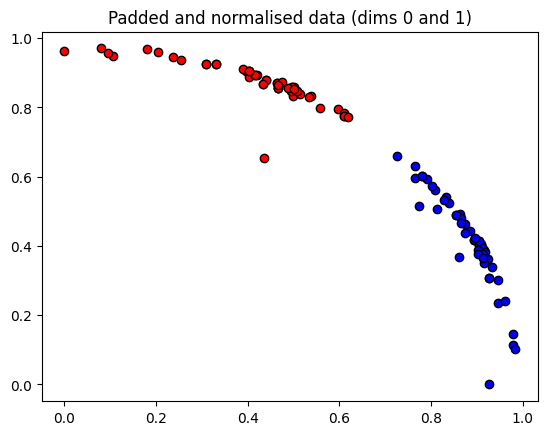

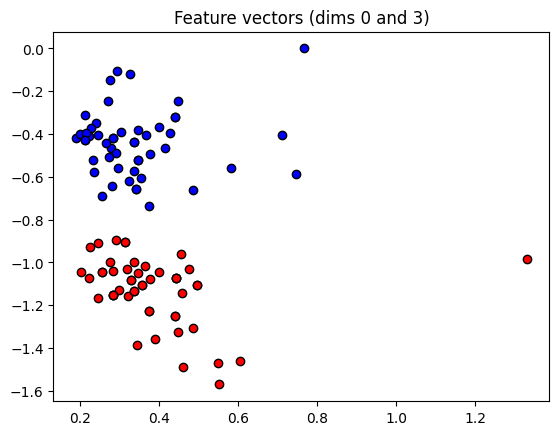

In [13]:
plt.figure()
plt.scatter(X[:, 0][Y == 1], X[:, 1][Y == 1], c="b", marker="o", ec="k")
plt.scatter(X[:, 0][Y == -1], X[:, 1][Y == -1], c="r", marker="o", ec="k")
plt.title("Original data")
plt.show()

plt.figure()
dim1 = 0
dim2 = 1
plt.scatter(X_norm[:, dim1][Y == 1], X_norm[:, dim2][Y == 1], c="b", marker="o", ec="k")
plt.scatter(X_norm[:, dim1][Y == -1], X_norm[:, dim2][Y == -1], c="r", marker="o", ec="k")
plt.title(f"Padded and normalised data (dims {dim1} and {dim2})")
plt.show()

plt.figure()
dim1 = 0
dim2 = 3
plt.scatter(features[:, dim1][Y == 1], features[:, dim2][Y == 1], c="b", marker="o", ec="k")
plt.scatter(features[:, dim1][Y == -1], features[:, dim2][Y == -1], c="r", marker="o", ec="k")
plt.title(f"Feature vectors (dims {dim1} and {dim2})")
plt.show()

In [14]:
num_data = len(Y)
num_train = int(0.75 * num_data)

index = np.random.permutation(range(num_data))

feats_train = features[index[:num_train]]
Y_train = Y[index[:num_train]]

feats_val = features[index[num_train:]]
Y_val = Y[index[num_train:]]

X_train = X[index[:num_train]]
X_val = X[index[num_train:]]

In [15]:
print(feats_train.shape, Y_train.shape)
print(feats_train[0], Y_train[0])

(75, 5) (75,)
[ 0.35754484 -0.78539816  0.78539816 -1.10714872  1.10714872] -1.0


In [16]:
num_qubits = 2
num_layers = 6

weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)
print(f"Weights: ", weights_init)
print(f"Bias: ", bias_init)

Weights:  [[[ 0.00425393 -0.00027971  0.0147599 ]
  [ 0.0064678  -0.00364334 -0.00678777]]

 [[-0.00353628 -0.00740747 -0.00675022]
  [-0.00132784  0.00619801  0.01791168]]

 [[ 0.00171    -0.01725671  0.00160659]
  [-0.00858985 -0.00206421  0.00488426]]

 [[-0.00838331  0.00381164 -0.00990903]
  [ 0.0101788   0.00341587 -0.01250886]]

 [[ 0.00925251 -0.00904786  0.01843692]
  [ 0.01525507 -0.01445536  0.00377161]]

 [[-0.00070557  0.0060416   0.00472149]
  [ 0.00819917  0.0090752  -0.00585823]]]
Bias:  0.0


In [17]:
opt = NesterovMomentumOptimizer(0.01)
batch_size = 5

weights = weights_init
bias = bias_init

for it in range(60):

    batch_index = np.random.randint(0, num_train, (batch_size,))
    
    feats_train_batch = feats_train[batch_index]
    Y_train_batch = Y_train[batch_index]

    weights, bias = opt.step(cost, weights, bias, X=feats_train_batch, Y=Y_train_batch)

    predictions_train = np.sign(variational_classifier(weights, bias, feats_train.T))
    predictions_val = np.sign(variational_classifier(weights, bias, feats_val.T))

    acc_train = accuracy(Y_train, predictions_train)
    acc_val = accuracy(Y_val, predictions_val)

    if (it + 1) % 2 == 0:
        _cost = cost(weights, bias, features, Y)

        print(
            f"Iter: {it + 1:5d} | Cost: {_cost:0.7f} | "
            f"Acc train: {acc_train:0.7f} | Acc validation: {acc_val:0.7f}"
        )

Iter:     2 | Cost: 1.6577375 | Acc train: 0.4666667 | Acc validation: 0.6000000
Iter:     4 | Cost: 1.2012704 | Acc train: 0.4800000 | Acc validation: 0.6000000
Iter:     6 | Cost: 0.9744663 | Acc train: 0.4800000 | Acc validation: 0.7600000
Iter:     8 | Cost: 0.9719951 | Acc train: 0.6400000 | Acc validation: 0.6000000
Iter:    10 | Cost: 0.9813387 | Acc train: 0.5600000 | Acc validation: 0.4400000
Iter:    12 | Cost: 0.9280434 | Acc train: 0.5733333 | Acc validation: 0.8000000
Iter:    14 | Cost: 0.9744214 | Acc train: 0.4533333 | Acc validation: 0.6000000
Iter:    16 | Cost: 0.9957965 | Acc train: 0.4666667 | Acc validation: 0.6000000
Iter:    18 | Cost: 0.9240688 | Acc train: 0.4800000 | Acc validation: 0.6400000
Iter:    20 | Cost: 0.8494333 | Acc train: 0.8266667 | Acc validation: 0.9200000
Iter:    22 | Cost: 0.8237044 | Acc train: 0.6133333 | Acc validation: 0.5600000
Iter:    24 | Cost: 0.7817319 | Acc train: 0.6133333 | Acc validation: 0.5600000
Iter:    26 | Cost: 0.709786

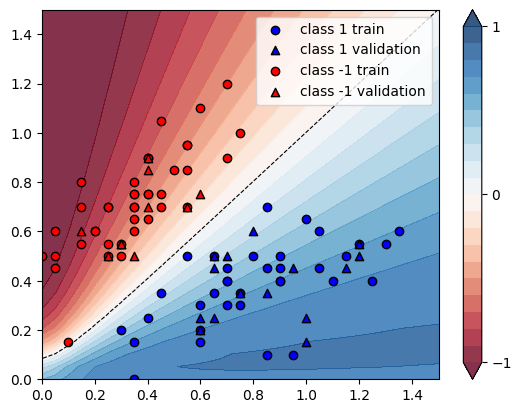

In [18]:
plt.figure()
cm = plt.cm.RdBu

# make data for decision regions
xx, yy = np.meshgrid(np.linspace(0.0, 1.5, 30), np.linspace(0.0, 1.5, 30))
X_grid = [np.array([x, y]) for x, y in zip(xx.flatten(), yy.flatten())]

# preprocess grid points like data inputs above
padding = 0.1 * np.ones((len(X_grid), 2))
X_grid = np.c_[X_grid, padding]  # pad each input
normalization = np.sqrt(np.sum(X_grid**2, -1))
X_grid = (X_grid.T / normalization).T  # normalize each input
features_grid = np.array([get_angles(x) for x in X_grid])  # angles are new features
predictions_grid = variational_classifier(weights, bias, features_grid.T)
Z = np.reshape(predictions_grid, xx.shape)

# plot decision regions
levels = np.arange(-1, 1.1, 0.1)
cnt = plt.contourf(xx, yy, Z, levels=levels, cmap=cm, alpha=0.8, extend="both")
plt.contour(xx, yy, Z, levels=[0.0], colors=("black",), linestyles=("--",), linewidths=(0.8,))
plt.colorbar(cnt, ticks=[-1, 0, 1])

# plot data
for color, label in zip(["b", "r"], [1, -1]):
    plot_x = X_train[:, 0][Y_train == label]
    plot_y = X_train[:, 1][Y_train == label]
    plt.scatter(plot_x, plot_y, c=color, marker="o", ec="k", label=f"class {label} train")
    plot_x = (X_val[:, 0][Y_val == label],)
    plot_y = (X_val[:, 1][Y_val == label],)
    plt.scatter(plot_x, plot_y, c=color, marker="^", ec="k", label=f"class {label} validation")

plt.legend()
plt.show()